# Árbol de Decisión y Bosque aleatorio 

Pamela Cerdas 

## Parte 1: árbol de decisión  (Decision Tree)


In [2]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# importar librerias
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

In [4]:
mydata= load_iris()

X = mydata.data
Y = mydata.target # Etiquetas 

print (X.shape)
print (Y.shape)


(150, 4)
(150,)


In [5]:
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [7]:
# Triple particion de los datos en entrenamiento, validacion y prueba
X_tv, X_test, y_tv, y_test = train_test_split(X, Y, test_size=.2, shuffle=True, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=.25, shuffle=True, random_state=1)

print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de validación:', X_val.shape)
print('Tamaño del conjunto de prueba', X_test.shape)

Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


{'whiskers': [<matplotlib.lines.Line2D at 0x1bfcfe4e7b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1bfcfe4ea50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bfcfe4e660>,
 'medians': [<matplotlib.lines.Line2D at 0x1bfcfe4eba0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1bfcfe4ecf0>,
 'means': []}

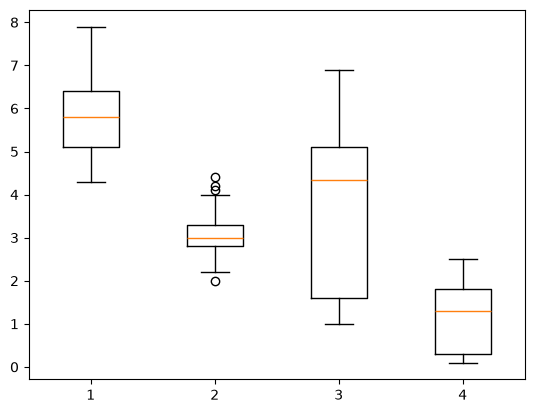

In [11]:
plt.boxplot(X, label=mydata.feature_names)

Text(0.5, 1.0, 'Boxplot de las características del iris')

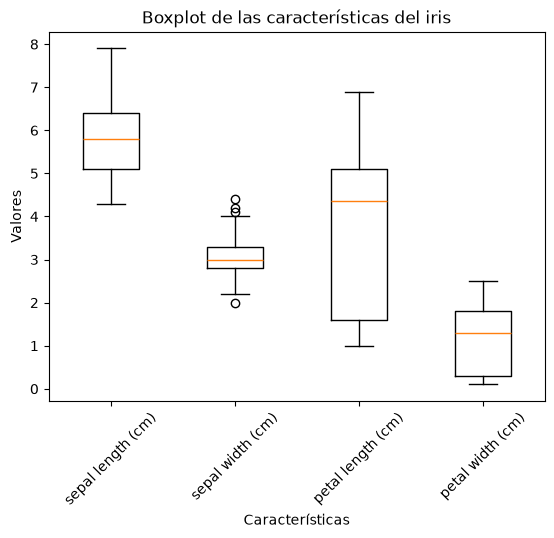

In [13]:
plt.boxplot(X)
plt.xticks([1, 2, 3, 4], mydata.feature_names, rotation=45)
plt.xlabel('Características')
plt.ylabel('Valores')
plt.title('Boxplot de las características del iris')   # codigo que paso juan padilla

{'whiskers': [<matplotlib.lines.Line2D at 0x1bfcfec42f0>,
 'caps': [<matplotlib.lines.Line2D at 0x1bfcfec4590>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bfcfec41a0>,
 'medians': [<matplotlib.lines.Line2D at 0x1bfcfec4830>,
 'fliers': [<matplotlib.lines.Line2D at 0x1bfcfec4980>,
 'means': []}

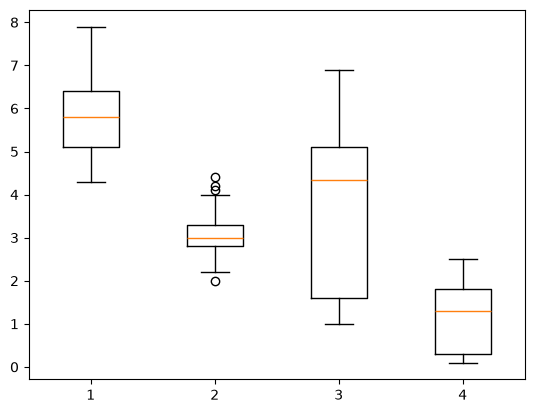

In [14]:
plt.boxplot(X, label=mydata.feature_names)

In [15]:
modeloDT = DecisionTreeClassifier()   # Incializamos el modelo con los hiperparámetros predeterminados.
clf = modeloDT.fit(X_train, y_train)   # Entrenamos con el conjunto de entrenamiento para obtener nuestro primer clasificador (clf)
# Podemos observar el desempeño en el conjunto de entrenamieto para verificar
# el subentrenamiento o sobreentrenamiento, pero no para evaluar el modelo en sí:
print('Exactitud en el conjunto de entrenamiento: %.2f' % clf.score(X_train, y_train))
# Así, el conjunto con el que nos interesa evaluar el desempeño es con los de validación,
# así que calculamos primero sus predicciones y después las usamos para evaluar el modelo:
predi = clf.predict(X_val)     # Obtenemos predicciones de 0s, 1s o 2s para cada clase
print('Exactitud en el conjunto de validación: %.2f' % clf.score(X_val, y_val))

Exactitud en el conjunto de entrenamiento: 1.00
Exactitud en el conjunto de validación: 0.97


In [16]:
  # Matriz de confusión para ver el desempeño del modelo

from sklearn.metrics import confusion_matrix


print(confusion_matrix(y_val, predi))

[[ 9  0  0]
 [ 0 10  0]
 [ 0  1 10]]


In [18]:
print(confusion_matrix(y_val, predi)/y_val.shape[0])

[[0.3        0.         0.        ]
 [0.         0.33333333 0.        ]
 [0.         0.03333333 0.33333333]]


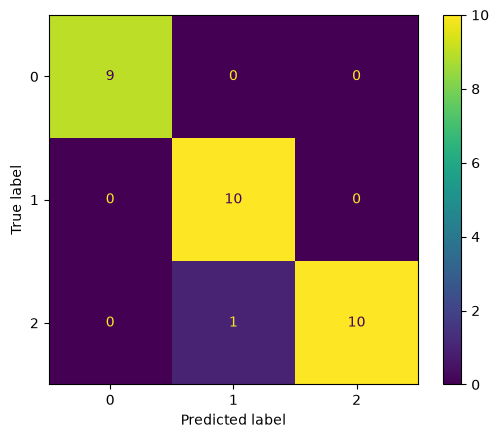

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, predi)
plt.show()

In [19]:
clf.score(X_val, y_val)

0.9666666666666667

In [20]:
pip install pydotplus

  Using cached pydotplus-2.0.2-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pydotplus
from IPython.display import Image

In [22]:
## Graficar el arbol de decisión 
from sklearn import tree 
import pydotplus
from IPython.display import Image 

In [23]:
# 1. Configurar el tamaño de la imagen plt.figure(figsize=(15, 10)) # 2. Dibujar el árbol directamente tree.plot_tree(decision_tree=clf, max_depth=None, feature_names=list(pd.DataFrame(X_train).columns.astype(str)), class_names=[str(c) for c in mydata.target_names], filled=True, proportion=False, fontsize=10) # 3. Mostrar la imagen en Jupyter plt.show()

## Parte 2 : Random Forest (Bosque Aleatorio)

Se simula un problema de clasificacion

In [25]:
import sklearn.datasets

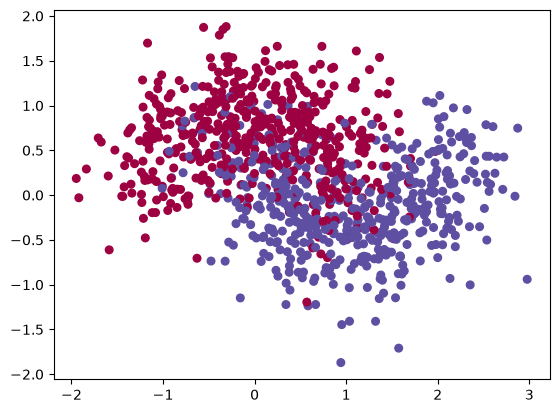

In [26]:
N=1000  # total de datos a generar en la muestra.

noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=0.4, random_state=17)

X, Y = noisy_data

 

plt.scatter(X[:,0], X[:,1], c=Y, s=30, cmap=plt.cm.Spectral);

In [27]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=.4, shuffle=True, random_state=17)

 

mimodelo = RandomForestClassifier()

 

clf = mimodelo.fit(Xtrain,Ytrain)

 

results = clf.predict(Xtest)

 

confusion_matrix(Ytest, results)

array([[167,  35],
       [ 31, 167]])

In [ ]:
clf.score(Xtest,Ytest)  # es la Exactitud (accuracy)

0.8325

In [ ]:
clf.feature_importances_  #importancia de cada caractetistica del modelo 

array([0.45651868, 0.54348132])

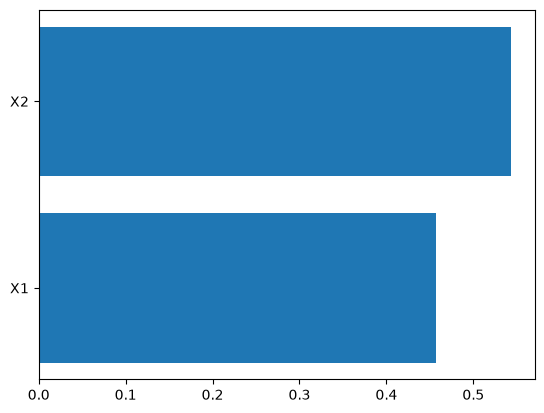

In [ ]:
plt.barh(['X1', 'X2'], width=clf.feature_importances_);

Como se muestra de las dos variables a estudiar la X2 es mas importante puesto que tiene mas representatividad 

In [ ]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:

 

mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.

                                   criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).

                                   max_depth=2, # Depth=k : máximo 2^k líneas/ramas.        

                                   min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.

                                   min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.

                                  ## max_features= 'auto',   # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).

                                   max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.

                                   bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.

                                   oob_score=True,  # en caso de utilizar Out-of-bag samples.

                                   verbose=0,     # tipo de despliega de información durante el entrenamiento.

                                   n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles. 

                                   max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0]. 

                                   random_state=19)



In [ ]:
clf2 = mimodelo2.fit(Xtrain,Ytrain)
clf2.score(Xtest,Ytest)

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.855